# Exercise #1

## Introduction

In this tutorial, we will explore a common failure in machine learning: the task of image classification using Convolutional Neural Networks (CNNs). Although this is a very common task, we will see that our training procedure ultimately fails. We invite you to solve the issue in the training process!

In [78]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'  # suppress TensorFlow warnings
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # use CPU only, uncomment this line to use GPU

import pandas as pd
import cv2

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

seed = 0 # fix random seed for reproducibility
tf.random.set_seed(seed)
np.random.seed(seed)

## Load dataset
First, we will load a prepared dataset that includes both training and test data.

In [2]:
def load_data(train_data_path, test_data_path):
    traindata = np.load(train_data_path)
    testdata = np.load(test_data_path)
    X_train = traindata['img']
    y_train = traindata['label']
    X_test = testdata['img']
    y_test = testdata['label']
    return (X_train, y_train), (X_test, y_test)

As the image dataset is in 8-bit unsigned integer format (`uint8`, with values ranging from 0 to 255), it is necessary to convert it to `float32` by normalizing the values. This conversion allows neural networks to process the data.

Label is an integer and takes the values 0, 1, and 2, representing 'circle', 'triangle', and 'square', respectively.

In [3]:
label_name = ['circle', 'triangle', 'square']
(X_train, y_train), (X_test, y_test) = load_data('../data/classification_1_train.npz', '../data/classification_test.npz')

# normalize image data (uint8 [0-255] -> float32 [0.0-1.0])
X_train = (X_train / 255).astype(np.float32)
X_test = (X_test / 255.).astype(np.float32)

Let's examine the size of the loaded dataset.

In [4]:
print('X_train.shape: ', X_train.shape)
print('Y_train.shape: ', y_train.shape)
print('X_test.shape:  ', X_test.shape)
print('Y_test.shape:  ', y_test.shape)

X_train.shape:  (60000, 36, 36, 3)
Y_train.shape:  (60000,)
X_test.shape:   (10000, 36, 36, 3)
Y_test.shape:   (10000,)


Additionally, let's inspect the images in the loaded dataset. To achieve this, we will display the first 36 images along with their labels from both the training and test data.

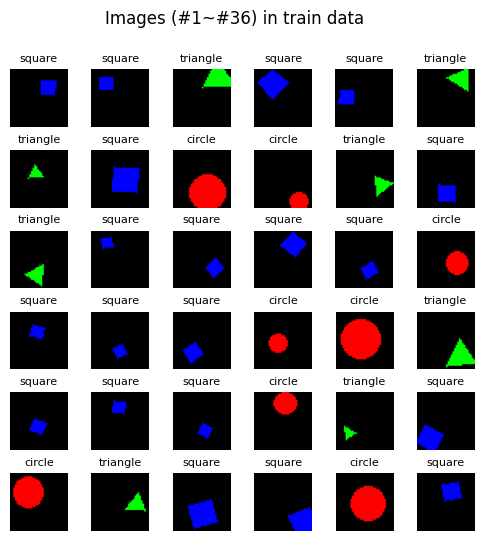

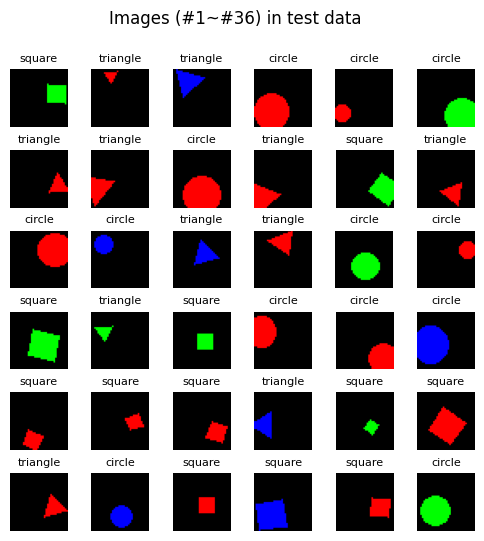

In [5]:
def plot_image(X, y):
    plt.figure(figsize=(6,6))
    for i in range(6*6):
        plt.subplot(6,6,i+1)
        plt.imshow(X[i], cmap='gray')  # cmap='gray' displays an image in black and white for monotone images and in color for rgb images. 
        plt.axis('off')
        plt.title(f'{label_name[y[i]]}', fontsize=8)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

plot_image(X_train, y_train)
plt.suptitle('Images (#1~#36) in train data')
plt.show()

plot_image(X_test, y_test)
plt.suptitle('Images (#1~#36) in test data')
plt.show()

## EDA dataset

### Class balance

In [17]:
def eda_class_balance(y, label_name=label_name):
    """Draw bar chart for classes"""

    if len(label_name) != len(set(y)):
        print("Mismatch labels and labels' names")
        return

    num_examples = [list(y).count(i) for i in set(list(y))]
    # Bar chart with text labels
    plt.figure(figsize=(10, 5))
    bars = plt.bar(label_name, num_examples, color=['blue', 'green', 'red'])

    # Add text labels on top of each bar
    for bar, num in zip(bars, num_examples):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, num,
                ha='center', va='bottom')

    plt.xlabel('Classes')
    plt.ylabel('Number of Examples')
    plt.title('Number of Examples per Class (Bar Chart with Labels)')
    plt.show()


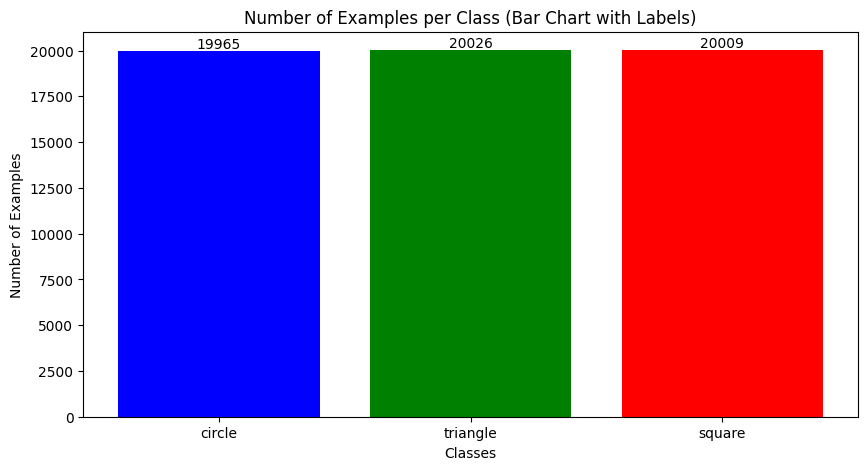

In [18]:
eda_class_balance(y_train)

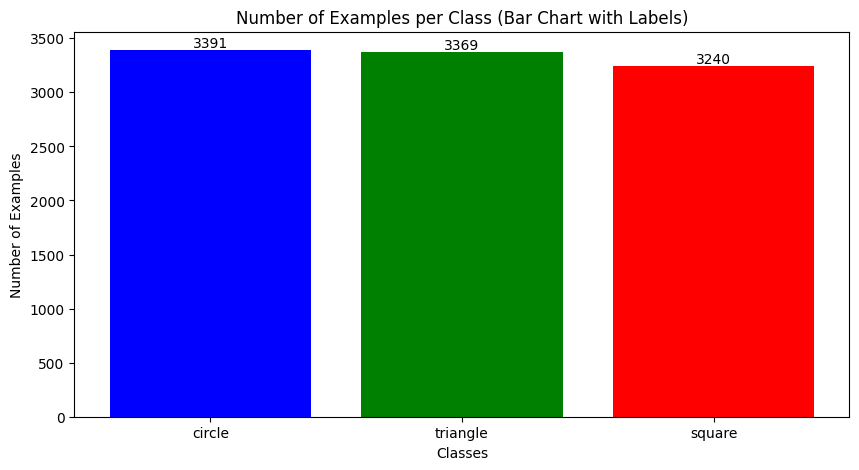

In [19]:
eda_class_balance(y_test)

<b>Insight: Class balance

### Color of each class

In [37]:
# Check whether 2 chanels is black, only 1 channel is having color?
for x_index, x in enumerate(X_train):
    r_sum = np.sum(x[:, :, 0])
    g_sum = np.sum(x[:, :, 1])
    b_sum = np.sum(x[:, :, 2])

    color_check = [1 if color > 0 else 0 for color in [r_sum, g_sum, b_sum]]
    color_check = sum(color_check)

    if color_check != 1:
        print(x_index, color_check, [r_sum, g_sum, b_sum])

for x_index, x in enumerate(X_test):
    r_sum = np.sum(x[:, :, 0])
    g_sum = np.sum(x[:, :, 1])
    b_sum = np.sum(x[:, :, 2])

    color_check = [1 if color > 0 else 0 for color in [r_sum, g_sum, b_sum]]
    color_check = sum(color_check)

    if color_check != 1:
        print(x_index, color_check, [r_sum, g_sum, b_sum])

<b> Insight: 100% data have only 1 channel color

In [74]:
def check_color_of_classes(X, y):
    
    # -----------------------------------------------------
    # Find df part
    # -----------------------------------------------------
    color = ["red", "green", "blue"]

    df_color = pd.DataFrame(columns=["label", "color"])

    for x_index, x in enumerate(X):
        label = label_name[y[x_index]]
        
        r_sum = np.sum(x[:, :, 0])
        g_sum = np.sum(x[:, :, 1])
        b_sum = np.sum(x[:, :, 2])

        color_found = color[np.argmax([r_sum, g_sum, b_sum])]
        
        new_row = {"label": label, "color": color_found}
        df_color.loc[len(df_color)] = new_row

    # -----------------------------------------------------
    # Draw part
    # -----------------------------------------------------
    # Sample data: 3 groups with 3 subgroups each
    groups = label_name
    subgroups = ["red", "green", "blue"]
    values = [len(df_color[(df_color["label"]==label) & (df_color["color"]==color_current)])
              for label in label_name
              for color_current in color]
    values = np.array(values).reshape(3, 3)
    
    print(values)

    # Plotting the bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    index = np.arange(len(groups))
    bar_width = 0.2
    opacity = 0.8

    for i, subgroup in enumerate(subgroups):
        rects = ax.bar(index + i * bar_width, values[:, i], bar_width,
                    alpha=opacity,
                    label=color[i%3], color=color[i])

    ax.set_xlabel('Groups')
    ax.set_ylabel('Values')
    ax.set_title('Values per Labels and Colors')
    ax.set_xticks(index + bar_width * (len(subgroups) - 1) / 2)
    ax.set_xticklabels(groups)
    ax.legend()

    plt.tight_layout()
    plt.show()

[[19965     0     0]
 [    0 20026     0]
 [    0     0 20009]]


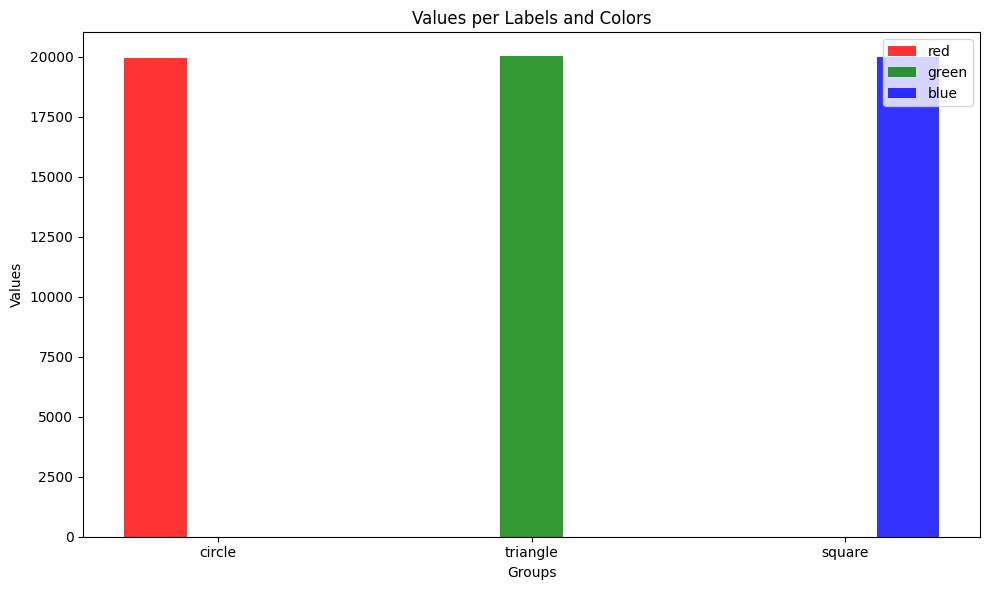

In [75]:
check_color_of_classes(X_train, y_train)

[[1158 1098 1135]
 [1122 1136 1111]
 [1043 1118 1079]]


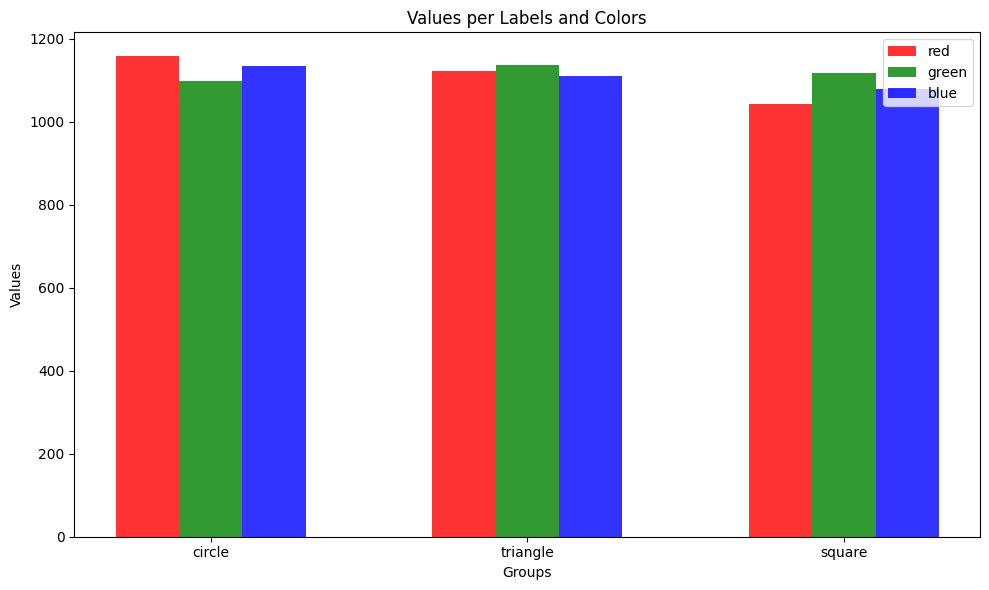

In [76]:
check_color_of_classes(X_test, y_test)

<b> Insight: Missing colors for training

### EDA: Position of object in image per class

In [131]:
def create_heatmap_position(X, y, label=""):

    X_check = []
    for index in range(len(X)):
        if (label == "") or (y[index]==label):
            X_check.append(X[index])

    heatmap = np.zeros((36,36))
    for x in X_check:
        x = x*255.0
        x = x.astype('uint8')
        x_gray = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
        _, x_bool = cv2.threshold(x_gray, 25, 255, cv2.THRESH_BINARY)
        heatmap = np.add(heatmap, x_bool)

    return heatmap

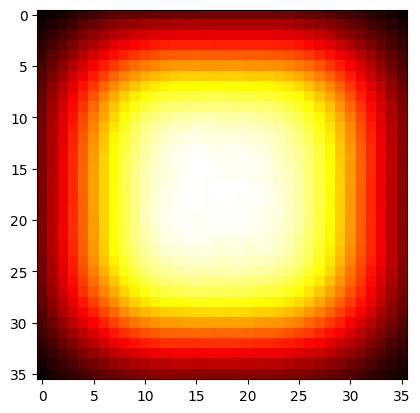

In [132]:
plt.imshow(create_heatmap_position(X_train, y_train), cmap='hot', interpolation='nearest')

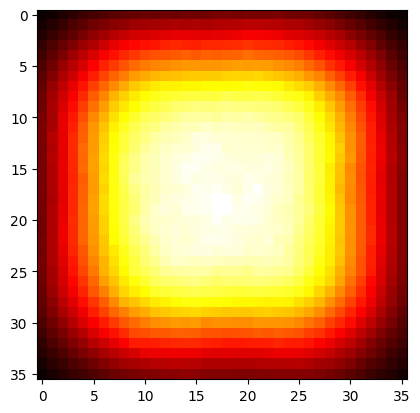

In [133]:
plt.imshow(create_heatmap_position(X_test, y_test), cmap='hot', interpolation='nearest')

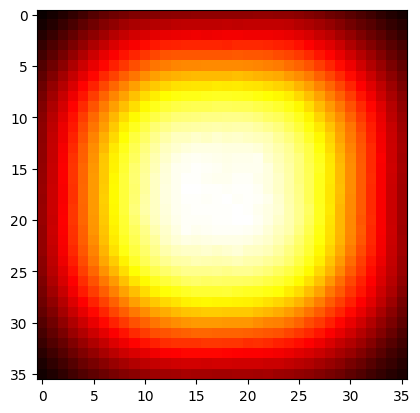

In [134]:
plt.imshow(create_heatmap_position(X_train, y_train, label=0), cmap='hot', interpolation='nearest')

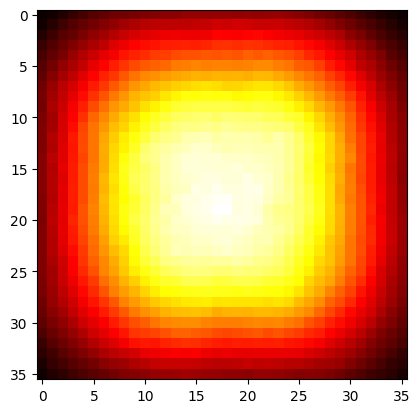

In [135]:
plt.imshow(create_heatmap_position(X_test, y_test, label=0), cmap='hot', interpolation='nearest')

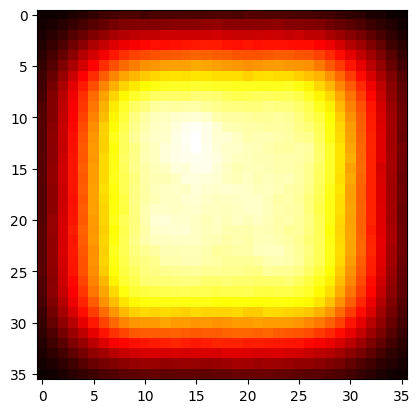

In [136]:
plt.imshow(create_heatmap_position(X_train, y_train, label=1), cmap='hot', interpolation='nearest')

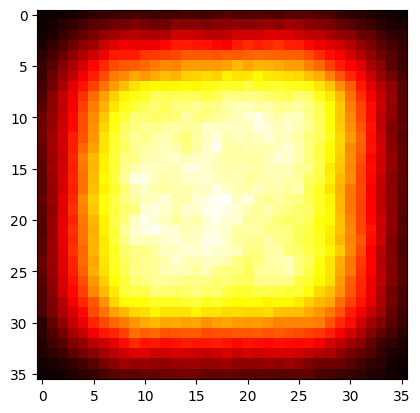

In [137]:
plt.imshow(create_heatmap_position(X_test, y_test, label=1), cmap='hot', interpolation='nearest')

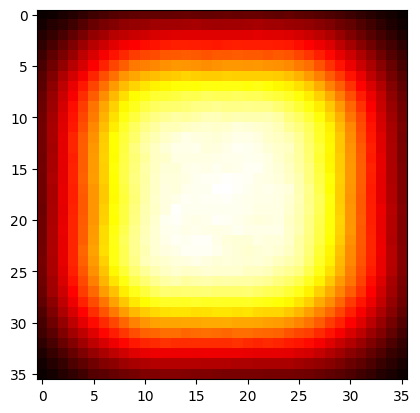

In [138]:
plt.imshow(create_heatmap_position(X_train, y_train, label=2), cmap='hot', interpolation='nearest')

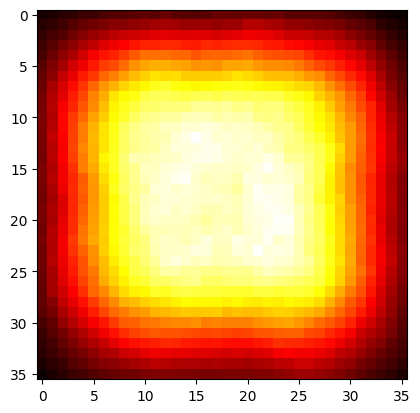

In [139]:
plt.imshow(create_heatmap_position(X_test, y_test, label=2), cmap='hot', interpolation='nearest')

<b> Insight: no different in position, but 'intensity' must be analysis more

### Brightness measurement

In [145]:
def brightness_measurement_each_set(X, y, label=""):
    X_check = []
    for index in range(len(X)):
        if (label == "") or (y[index]==label):
            X_check.append(X[index])

    values = []
    for x in X_check:
        x = x*255.0
        x = x.astype('uint8')
        x_hsv = cv2.cvtColor(x, cv2.COLOR_RGB2HSV)
        x_hsv = x_hsv[:, :, -1]
        x_hsv = int(np.average(x_hsv))
        values.append(x_hsv)

    return values


def brightness_measurement(label=""):
    train_hsv = brightness_measurement_each_set(X_train, y_train, label=label)
    test_hsv = brightness_measurement_each_set(X_test, y_test, label=label)
    # Plotting the histograms
    plt.figure(figsize=(8, 6))
    plt.hist(train_hsv, bins=range(min(min(train_hsv), min(test_hsv)), max(max(train_hsv), max(test_hsv)) + 1), alpha=0.5, label='x1', color='blue')
    plt.hist(test_hsv, bins=range(min(min(train_hsv), min(test_hsv)), max(max(train_hsv), max(test_hsv)) + 1), alpha=0.5, label='x2', color='orange')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.title('Histogram of Train and Test')
    plt.legend()
    plt.grid(True)
    plt.show()

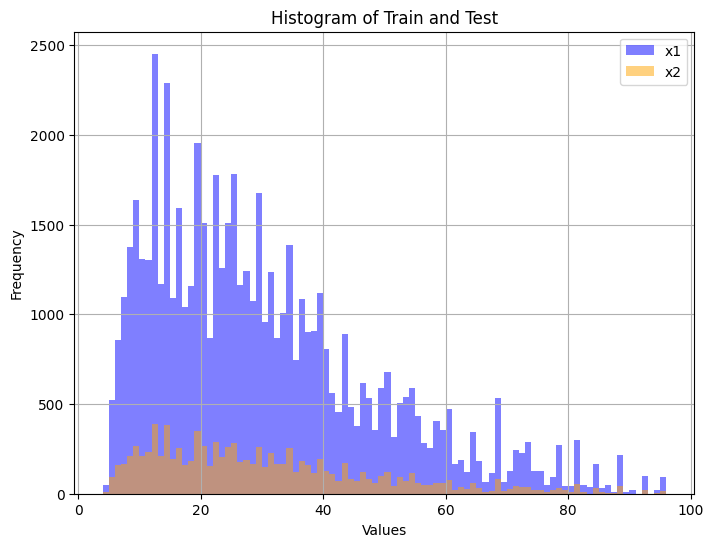

In [146]:
brightness_measurement()

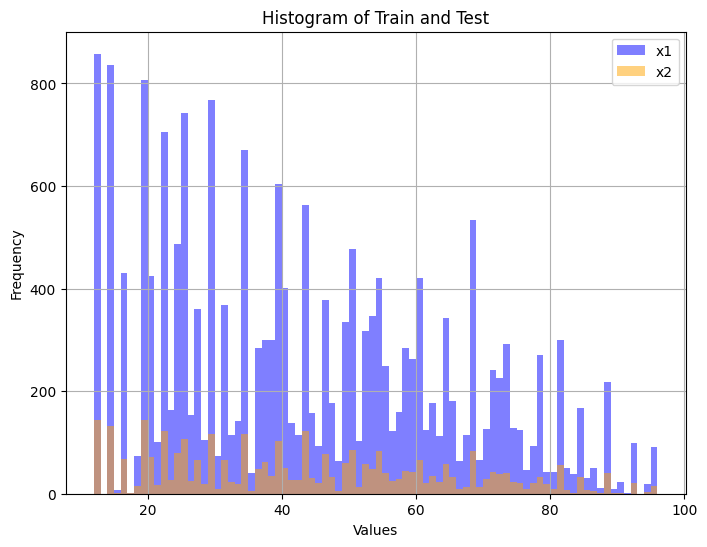

In [147]:
brightness_measurement(label=0)

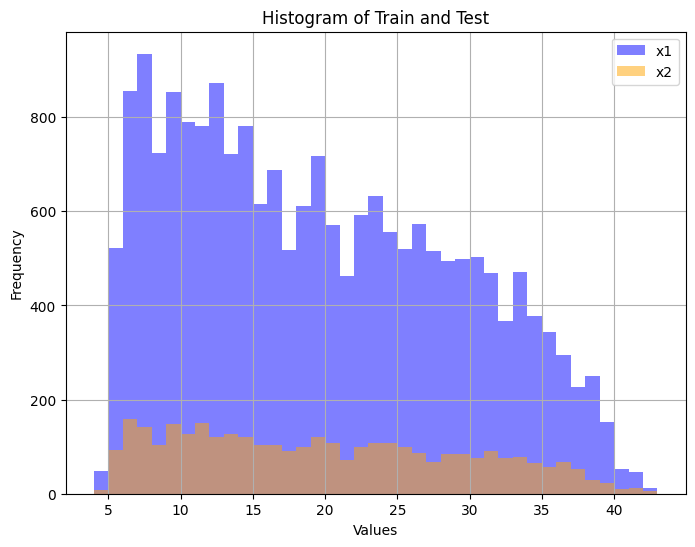

In [148]:
brightness_measurement(label=1)

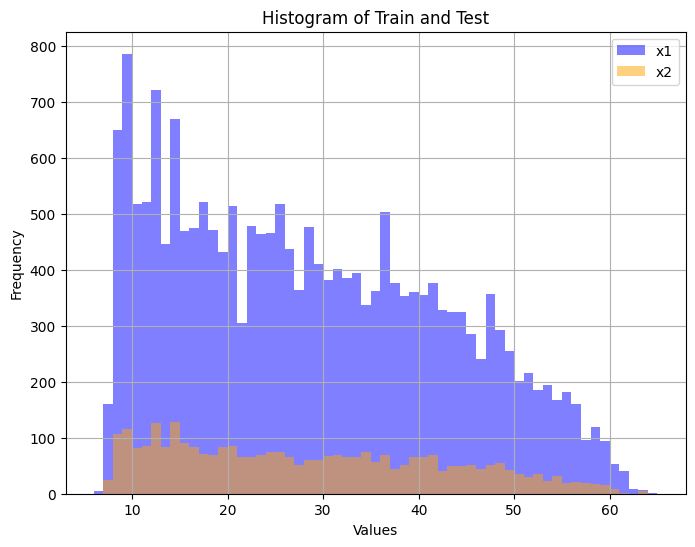

In [149]:
brightness_measurement(label=2)

<b> Insight: Different distribution for "brightness intensity" between train/test

## Training model

### Base model

#### Define the model
The next step is to define our neural network model. To create a CNN model for classification tasks, we need to set up the model to be suitable for the size of the processed images, including their height, width, and the number of channels (e.g., RGB), as well as the number of classes into which the model will classify the shapes.

Our goal is to train the neural network model to classify shapes (circles, triangles, and squares) in the images.

In [140]:
img_rows, img_cols, img_channel = X_train.shape[1:4] # size of height, width, channels
num_classes = 3 # number of classes

With those necessary numbers, finally we can define our CNN model. 

In [141]:
def get_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=input_shape),  
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(num_classes)
    ])
    return model

model = get_model(input_shape=(img_rows, img_cols, img_channel), num_classes=3)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

/Users/phucnt/anaconda3/envs/ds_minima/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 34, 34, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 17, 17, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 15, 15, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        10,803 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,571 (53.01 KB)

 Trainable params: 13,571 (53.01 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

Now let's train our model with the loaded images!

In [142]:
epochs = 5
batch_size = 32
result = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

print(f'train loss: {result.history["loss"][-1]}, train accuracy: {result.history["accuracy"][-1]}')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9874 - loss: 0.0532
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 1.0000 - loss: 3.3167e-06
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 1.0000 - loss: 6.0962e-07
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 1.0000 - loss: 1.6454e-07
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 1.0000 - loss: 5.1689e-08
train loss: 3.7953928000433734e-08, train accuracy: 1.0


#### Problem

The prediction accuracy on the training data is close to 100%, suggesting that the training was successful. To assess the performance of the trained model, let's evaluate it using the test data.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'test loss: {test_loss}, test accuracy: {test_acc}')

313/313 [==============================] - 0s 1ms/step - loss: 28.5613 - accuracy: 0.3373
test loss: 28.561311721801758, test accuracy: 0.33730000257492065


Oh dear! The accuracy of the model's predictions is only 30%, which is as low as if the classification were done by chance. Now, we must review our procedure to investigate the cause of this issue and find a solution.

### New model with fixing data problem

<ul>
    <li> Data problem is related to color range and intensity, class balance,position of object maybe not a problem.
    <li> Simple approach here is just make image binary
<ul>

#### Standarize data

In [164]:
X_train_new = []
X_test_new = []

for x in X_train:
    x = x*255.0
    x = x.astype('uint8')
    x = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
    x = x > 0
    X_train_new.append(x)

for x in X_test:
    x = x*255.0
    x = x.astype('uint8')
    x = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
    x = x > 0
    X_test_new.append(x)

X_train_new = np.array(X_train_new)
X_test_new = np.array(X_test_new)

#### Define a simple model

In [169]:
def get_model(input_shape, num_classes, drop_rate=0.5):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(16, 3, activation=None, padding='same',input_shape=input_shape),
        tf.keras.layers.Conv2D(16, 3, activation=None, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        
        tf.keras.layers.Conv2D(32, 3, activation=None, padding='same',),
        tf.keras.layers.Conv2D(32, 3, activation=None, padding='same',),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, 3, activation=None, padding='same',),
        tf.keras.layers.Conv2D(64, 3, activation=None, padding='same',),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(rate=drop_rate),
        tf.keras.layers.Dense(num_classes)
    ])
    return model

model = get_model(input_shape=(img_rows, img_cols, 1), num_classes=3)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

/Users/phucnt/anaconda3/envs/ds_minima/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 36, 36, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 36, 36, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 36, 36, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 36, 36, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 18, 18, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 18, 18, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 18, 18, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 18, 18, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 9, 9, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,315 (294.20 KB)

 Trainable params: 75,091 (293.32 KB)

 Non-trainable params: 224 (896.00 B)

In [170]:
epochs = 5
batch_size = 32
result = model.fit(X_train_new, y_train, epochs=epochs, batch_size=batch_size)

print(f'train loss: {result.history["loss"][-1]}, train accuracy: {result.history["accuracy"][-1]}')

Epoch 1/5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 167s 87ms/step - accuracy: 0.7908 - loss: 0.4901
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 206s 89ms/step - accuracy: 0.9942 - loss: 0.0169
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 164s 88ms/step - accuracy: 0.9961 - loss: 0.0132
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 165s 88ms/step - accuracy: 0.9968 - loss: 0.0103
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 165s 88ms/step - accuracy: 0.9964 - loss: 0.0129
train loss: 0.009272360242903233, train accuracy: 0.9974333047866821


In [171]:
test_loss, test_acc = model.evaluate(X_test_new, y_test)
print(f'test loss: {test_loss}, test accuracy: {test_acc}')

 21/313 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9977 - loss: 0.0091

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9994 - loss: 0.0020
test loss: 0.0008746667881496251, test accuracy: 0.9995999932289124
